<a href="https://colab.research.google.com/github/gayathris2025cse/Fundamentals-Of-Data-Science-Lab/blob/main/exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

file_path = next(iter(uploaded))
df = pd.read_csv(file_path)

print(df.head())

Saving SALES DATA - SALES DATA.csv to SALES DATA - SALES DATA (1).csv
         Date    Product  Sales  Quantity Region
0  01-01-2023  Product A    200         4  North
1  02-01-2023  Product B    150         3  South
2  03-01-2023  Product A    220         5  North
3  04-01-2023  Product C    300         6   East
4  05-01-2023  Product B    180         4   West


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Date        0
Product     0
Sales       0
Quantity    0
Region      0
dtype: int64


In [5]:
# Fill missing Sales values with mean
df['Sales'].fillna(df['Sales'].mean(), inplace=True)

# Drop rows with missing values in important columns
df.dropna(subset=['Product', 'Quantity', 'Region'], inplace=True)

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
Date        0
Product     0
Sales       0
Quantity    0
Region      0
dtype: int64


/tmp/ipykernel_637/742497901.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales'].fillna(df['Sales'].mean(), inplace=True)


In [6]:
print(df.describe())

            Sales   Quantity
count   16.000000  16.000000
mean   237.500000   5.375000
std     64.031242   1.746425
min    150.000000   3.000000
25%    187.500000   4.000000
50%    225.000000   5.500000
75%    302.500000   7.000000
max    340.000000   8.000000


In [7]:
product_summary = df.groupby('Product').agg({
    'Sales': 'sum',
    'Quantity': 'sum'
}).reset_index()

print(product_summary)

     Product  Sales  Quantity
0  Product A   1350        33
1  Product B    850        17
2  Product C   1600        36


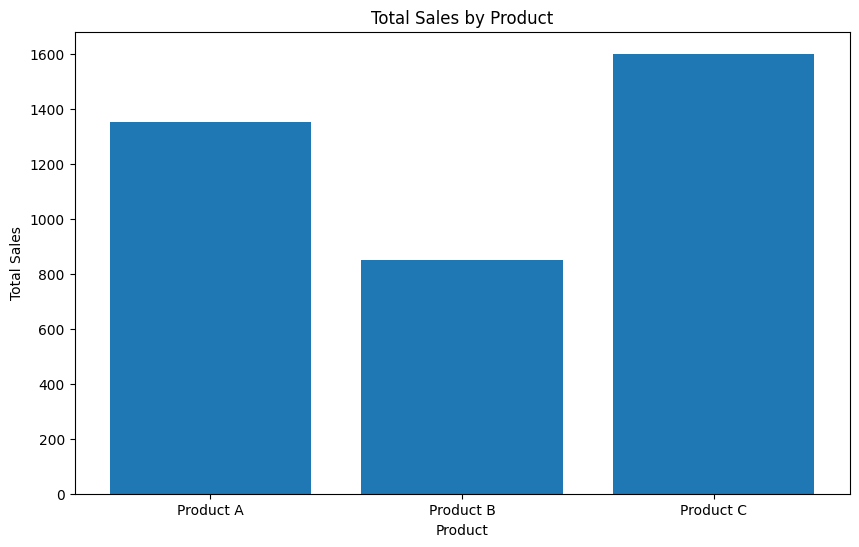

In [8]:
plt.figure(figsize=(10, 6))

plt.bar(product_summary['Product'],
        product_summary['Sales'])

plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.title('Total Sales by Product')

plt.show()

In [9]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(df['Date'].head())

0   2023-01-01
1   2023-01-02
2   2023-01-03
3   2023-01-04
4   2023-01-05
Name: Date, dtype: datetime64[ns]


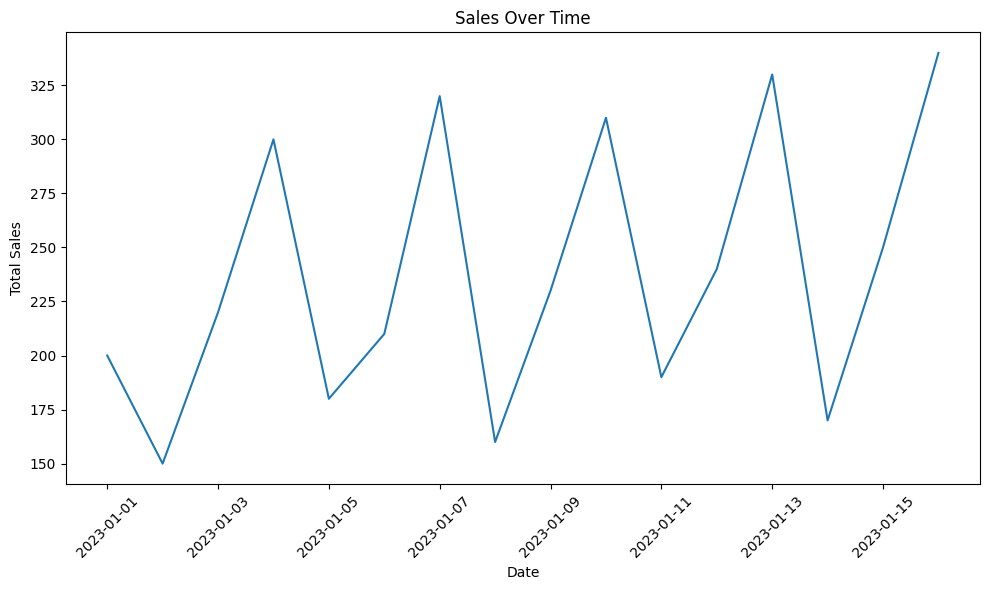

In [10]:
sales_over_time = df.groupby('Date').agg({
    'Sales': 'sum'
}).reset_index()

plt.figure(figsize=(10, 6))

plt.plot(
    sales_over_time['Date'],
    sales_over_time['Sales']
)

plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Sales Over Time')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [11]:
pivot_table = df.pivot_table(
    values='Sales',
    index='Region',
    columns='Product',
    aggfunc='sum',
    fill_value=0
)

print(pivot_table)

Product  Product A  Product B  Product C
Region                                  
East             0          0       1600
North         1350          0          0
South            0        480          0
West             0        370          0


In [12]:
correlation_matrix = df[['Sales', 'Quantity']].corr()

print(correlation_matrix)

             Sales  Quantity
Sales     1.000000  0.944922
Quantity  0.944922  1.000000


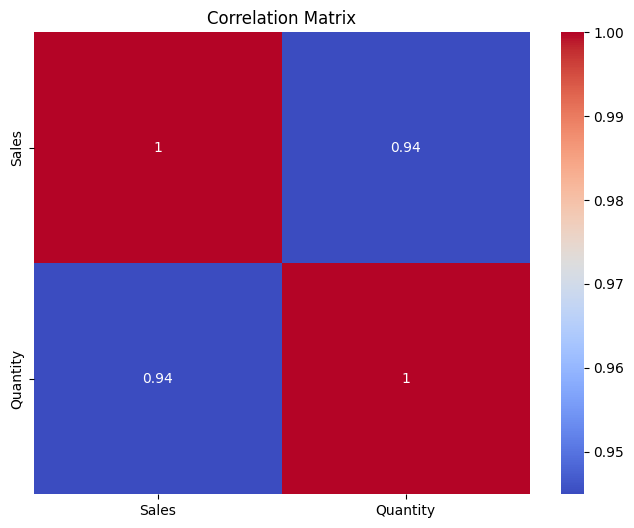

In [13]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

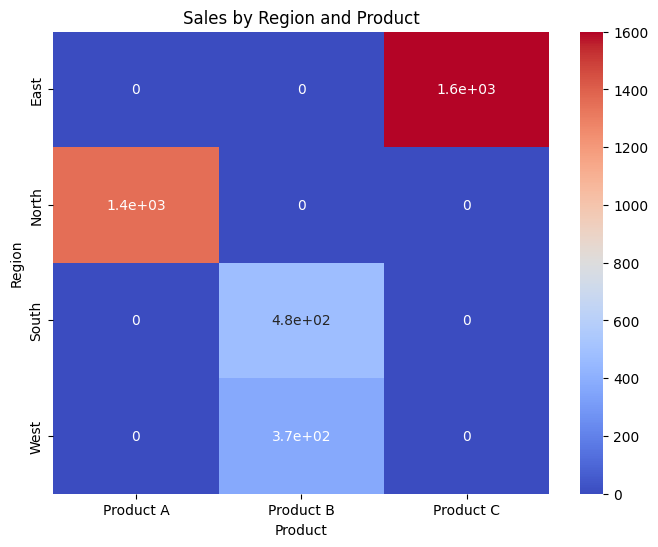

In [14]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap='coolwarm'
)

plt.title('Sales by Region and Product')
plt.xlabel('Product')
plt.ylabel('Region')

plt.show()